In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/flipkart_products.csv")

df.head()
df.shape

(80, 4)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product Name  80 non-null     object
 1   Price         80 non-null     object
 2   Rating        80 non-null     object
 3   Product Link  80 non-null     object
dtypes: object(4)
memory usage: 2.6+ KB


In [12]:
df.describe()

,Product Name,Price,Rating,Product Link
count,80,80,80,80
unique,76,70,1,80
top,Nut Urge CASHEW SPECIAL WHOLE 200gm+ALMOND BOL...,₹551,No Rating,https://www.flipkart.com/nature-aahar-mix-dry-...
freq,2,3,80,1


In [13]:
df.isnull().sum()

Product Name    0
Price           0
Rating          0
Product Link    0
dtype: int64

In [14]:
df["Price"] = (
    df["Price"]
    .str.replace("₹", "")
    .str.replace(",", "")
    .astype(float)
)

In [15]:
average_price = df["Price"].mean()

print("Average Price:", average_price)

Average Price: 509.35


In [16]:
highest_price = df["Price"].max()

print("Highest Price:", highest_price)

Highest Price: 3931.0


In [17]:
lowest_price = df["Price"].min()

print("Lowest Price:", lowest_price)

Lowest Price: 142.0


In [18]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.extract(r'(\d[\d,]*)')[0]
    .str.replace(",", "", regex=False)
)

df["Price"] = pd.to_numeric(df["Price"])

In [19]:
print("Mean:", np.mean(df["Price"]))

print("Median:", np.median(df["Price"]))

print("Maximum:", np.max(df["Price"]))

print("Minimum:", np.min(df["Price"]))

print("Standard Deviation:", np.std(df["Price"]))

Mean: 509.35
Median: 412.0
Maximum: 3931
Minimum: 142
Standard Deviation: 457.9998935589396


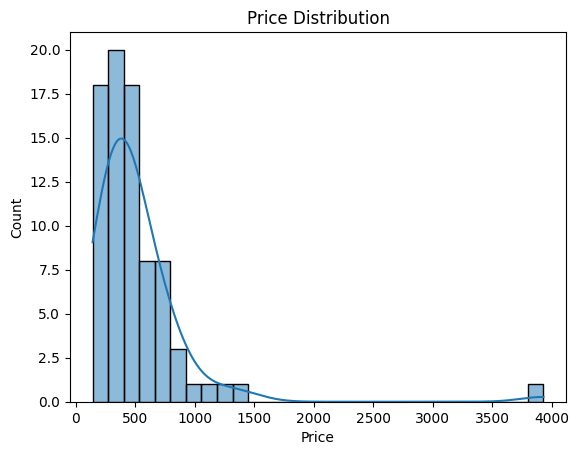

In [20]:
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")
plt.show()

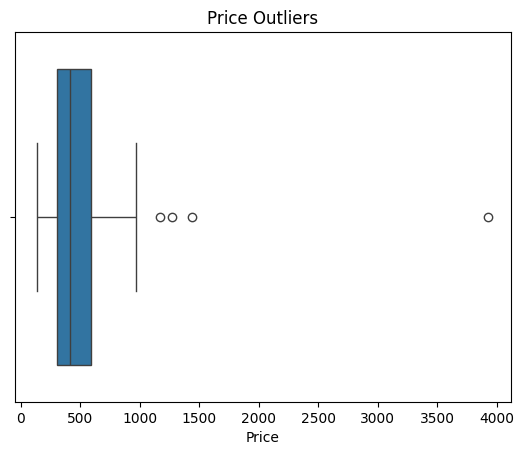

In [21]:
sns.boxplot(x=df["Price"])
plt.title("Price Outliers")
plt.show()

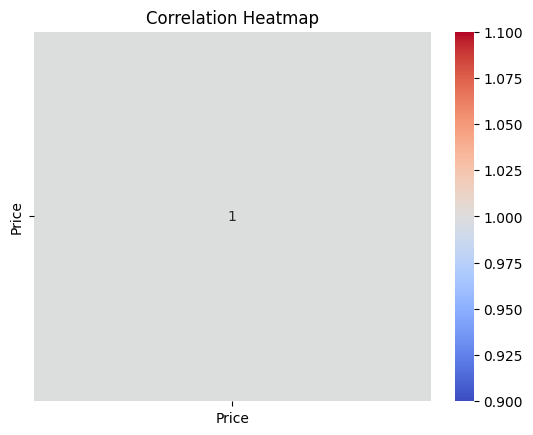

In [22]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()